# TEST Marie – Estimation du Redshift Photométrique

Pipeline complet basé sur le modèle `Model_multi_modal_simple` de Marie Treyer.  
Toute la configuration est centralisée dans `utils/config.py`.

**Données :** cubes multi-bandes 64×64×9 (sondages COSMOS et XMM-LSS)  
**Tâche :** régression du redshift photométrique (ZPHOT → ZSPEC)

In [3]:
import numpy as np
import glob
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import gdown
import matplotlib.pyplot as plt

## 1. Chargement des données

In [4]:
DATA_FOLDER = "redshift"
DATA_URL = "https://drive.google.com/drive/folders/1-tQH6rfB1XoF7ml98yqVn7Z2IQwGMUdK"

if os.path.exists(DATA_FOLDER) and glob.glob(os.path.join(DATA_FOLDER, "*.npz")):
    print(f"Dossier '{DATA_FOLDER}' déjà présent, pas de téléchargement.")
else:
    print("Téléchargement des données depuis Google Drive...")
    gdown.download_folder(DATA_URL, quiet=True, use_cookies=False)
    print("Téléchargement terminé.")

fichiers_npz = sorted(glob.glob(os.path.join(DATA_FOLDER, "*.npz")))
print(f"{len(fichiers_npz)} fichiers .npz trouvés :")
for f in fichiers_npz:
    print(f"  {os.path.basename(f)}")

Dossier 'redshift' déjà présent, pas de téléchargement.
8 fichiers .npz trouvés :
  COSMOS_v11_uijk_0001_photo_D.npz
  COSMOS_v11_uijk_0020_spec_D.npz
  COSMOS_v11_uijk_0073_spec_UD.npz
  COSMOS_v11_uijk_0213_photo_UD.npz
  XMM_LSS_v11_uijk_0006_spec_D.npz
  XMM_LSS_v11_uijk_0162_phot_D.npz
  XMM_LSS_v11_uijk_0162_phot_UD.npz
  XMM_LSS_v11_uijk_0177_spec_UD.npz


In [5]:
fichiers_npz = glob.glob('redshift/*.npz')
cosmos_files = [f for f in fichiers_npz if "COSMOS" in f]

# Listes séparées pour train et test
train_cubes_list = []
train_infos_list = []
train_flag_list = []

test_cubes_list = []
test_infos_list = []
test_flag_list = []

print(f"Chargement de {len(cosmos_files)} fichiers COSMOS.")

for fichier in cosmos_files:
    try:
        data = np.load(fichier, allow_pickle=True)
        
        # 'info' est un array structuré. 'dtype.names' donne les noms des colonnes.
        info_fields = data['info'].dtype.names
        
        # On vérifie si la *colonne* 'ZSPEC' existe dans ce fichier
        if 'ZSPEC' in info_fields:
            # Ce fichier contient des données de TEST (il a la colonne ZSPEC)
            test_cubes_list.append(data['cube'])
            test_infos_list.append(data['info'])
            test_flag_list.append(data['flag'])
        else:
            # Ce fichier contient des données de TRAIN (pas de colonne ZSPEC)
            train_cubes_list.append(data['cube'])
            train_infos_list.append(data['info'])
            train_flag_list.append(data['flag'])
            
            
    except Exception as e:
        print(f":x: Erreur en chargeant {fichier}: {e}")

print("Chargement terminé.")

Chargement de 4 fichiers COSMOS.
Chargement terminé.


In [6]:
# --- Concaténation des listes déjà filtrées COSMOS ---
X_train     = np.concatenate(train_cubes_list, axis=0)
infos_train = np.concatenate(train_infos_list)
flags_train = np.concatenate(train_flag_list)
y_train     = infos_train["ZPHOT"]

X_test      = np.concatenate(test_cubes_list, axis=0)
infos_test  = np.concatenate(test_infos_list)
flags_test  = np.concatenate(test_flag_list)
y_test_raw  = infos_test["ZSPEC"]

# Filtrer les ZSPEC invalides (NaN)
mask_valid = ~np.isnan(y_test_raw)
X_test    = X_test[mask_valid]
y_test    = y_test_raw[mask_valid]
flags_test = flags_test[mask_valid]

print(f"Train : {X_train.shape}  |  y_train : {y_train.shape}  (ZPHOT)")
print(f"Test  : {X_test.shape}   |  y_test  : {y_test.shape}   (ZSPEC valides)")
print(f"Plage ZPHOT : [{y_train.min():.3f}, {y_train.max():.3f}]")
print(f"Plage ZSPEC : [{y_test.min():.3f},  {y_test.max():.3f}]")

Train : (12497, 64, 64, 9)  |  y_train : (12497,)  (ZPHOT)
Test  : (27, 64, 64, 9)   |  y_test  : (27,)   (ZSPEC valides)
Plage ZPHOT : [0.010, 5.965]
Plage ZSPEC : [0.000,  5.720]


## 2. Import du modèle et de la configuration

In [7]:
import importlib.util
import types
import torch

chemin_parent = os.path.abspath(os.path.join(DATA_FOLDER, "Marie Treyer"))

# Try project-root utils/ first, then redshift/Marie Treyer/utils/
_candidates = [
    os.path.join(os.path.abspath("utils"), "config.py"),
    os.path.join(chemin_parent, "utils", "config.py"),
]
_config_path = next((p for p in _candidates if os.path.exists(p)), None)

if _config_path:
    _spec = importlib.util.spec_from_file_location("config", _config_path)
    config = importlib.util.module_from_spec(_spec)
    _spec.loader.exec_module(config)
else:
    config = types.SimpleNamespace(CONFIG={})

# Patch any keys missing from older config versions
_DEFAULTS = {
    "DEVICE":                               "cuda" if torch.cuda.is_available() else "cpu",
    "SEED":                                 42,
    "BATCH_SIZE":                           32,
    "NUM_WORKERS":                          0,
    "PIN_MEMORY":                           False,
    "LR":                                   1e-3,
    "EPOCHS":                               30,
    "MODALITIES":                           [list(range(9))],
    "MAGS_INPUT_SIZE":                      None,
    "PARALLEL_BEFORE_INCEPTION_ARCHI":      [32, 32],
    "PARALLEL_INCEPTION_ARCHI":             [36, 32, 32, 32, 42, 42],
    "PARALLEL_POOLING_BEFORE_INCEPTIONS":   [True, False, False, False, False, False],
    "INCEPTION_ARCHI":                      [109, 101, 101, 101, 156, 156],
    "POOLING_BEFORE_INCEPTIONS":            [False, True, False, True, False, False],
    "FIRST_FC_DIM":                         1024,
    "CLASSIFICATION_FCS_ARCHI":             [1024],
    "REGRESSION_FCS_ARCHI":                 [512],
    "BATCH_NORM":                           True,
    "ONE_CONV_AFTER_INCEPTIONS":            False,
    "USE_CROSS_FUSION":                     False,
    "USE_MODALITY_TRANSFORMERS":            False,
    "USE_CNN_ADV":                          False,
    "CNN_INPUT_STAGE":                      1,
    "MODALITY_DROP_OUT":                    None,
    "MOD_DO_PROBA":                         0.3,
    "SPECEFIC_MODALITIES_SWITCH_OFF":       None,
    "VAL_MODALITIES_TO_SWITCH_OFF":         None,
}
for k, v in _DEFAULTS.items():
    config.CONFIG.setdefault(k, v)

# Enregistrer sous les deux noms pour que model_multi_modal_simple.py trouve utils.config
sys.modules["config"]       = config
sys.modules["utils.config"] = config

# Ajouter les chemins pour les autres imports du modele
chemin_utils = os.path.dirname(_config_path) if _config_path else os.path.abspath("utils")
project_root = os.path.abspath(".")
for p in [chemin_parent, chemin_utils, project_root]:
    if p not in sys.path:
        sys.path.insert(0, p)

from model_multi_modal_simple import Model_multi_modal_simple

print("Device :", config.CONFIG["DEVICE"])
print("Config chargee depuis :", _config_path or "(valeurs par defaut integrees)")
print("Cles CONFIG disponibles :", list(config.CONFIG.keys()))


Device : cuda
Config chargee depuis : /content/redshift/Marie Treyer/utils/config.py
Cles CONFIG disponibles : ['DEVICE', 'SEED', 'DATA_FOLDER', 'DATA_URL', 'INPUT_SHAPE', 'N_BANDS', 'BATCH_SIZE', 'NUM_WORKERS', 'PIN_MEMORY', 'LR', 'EPOCHS', 'MODALITIES', 'MAGS_INPUT_SIZE', 'PARALLEL_BEFORE_INCEPTION_ARCHI', 'PARALLEL_INCEPTION_ARCHI', 'PARALLEL_POOLING_BEFORE_INCEPTIONS', 'INCEPTION_ARCHI', 'POOLING_BEFORE_INCEPTIONS', 'FIRST_FC_DIM', 'CLASSIFICATION_FCS_ARCHI', 'REGRESSION_FCS_ARCHI', 'BATCH_NORM', 'ONE_CONV_AFTER_INCEPTIONS', 'USE_CROSS_FUSION', 'USE_MODALITY_TRANSFORMERS', 'USE_CNN_ADV', 'CNN_INPUT_STAGE', 'MODALITY_DROP_OUT', 'MOD_DO_PROBA', 'SPECEFIC_MODALITIES_SWITCH_OFF', 'VAL_MODALITIES_TO_SWITCH_OFF']


## 3. Préparation des tenseurs et du DataLoader

In [8]:
torch.manual_seed(config.CONFIG["SEED"])
np.random.seed(config.CONFIG["SEED"])

# Les cubes sont (N, H, W, C) ; PyTorch attend (N, C, H, W).
# np.ascontiguousarray fait la transposition + copie en une seule passe (float32),
# et torch.from_numpy partage ce buffer sans copie supplémentaire.
# Cela réduit le pic mémoire de ~3 copies à ~1 copie par rapport à torch.tensor(...copy()).
X_train_np = np.ascontiguousarray(np.transpose(X_train, (0, 3, 1, 2)), dtype=np.float32)
X_test_np  = np.ascontiguousarray(np.transpose(X_test,  (0, 3, 1, 2)), dtype=np.float32)

X_train_t = torch.from_numpy(X_train_np)
X_test_t  = torch.from_numpy(X_test_np)

y_train_t = torch.tensor(y_train.astype(np.float32)).unsqueeze(1)
y_test_t  = torch.tensor(y_test.astype(np.float32)).unsqueeze(1)

train_ds     = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(
    train_ds,
    batch_size=config.CONFIG["BATCH_SIZE"],
    shuffle=True,
    num_workers=config.CONFIG["NUM_WORKERS"],
    pin_memory=config.CONFIG["PIN_MEMORY"],
)

print(f"X_train tensor : {X_train_t.shape}")
print(f"X_test  tensor : {X_test_t.shape}")
print(f"Batches par époque : {len(train_loader)}")

X_train tensor : torch.Size([12497, 9, 64, 64])
X_test  tensor : torch.Size([27, 9, 64, 64])
Batches par époque : 391


## 4. Instanciation du modèle

In [9]:
import torch

# Safety patch: fill any keys missing from older config versions
_ARCH_DEFAULTS = {
    "MODALITIES":                           [list(range(9))],
    "MAGS_INPUT_SIZE":                      None,
    "PARALLEL_BEFORE_INCEPTION_ARCHI":      [32, 32],
    "PARALLEL_INCEPTION_ARCHI":             [36, 32, 32, 32, 42, 42],
    "PARALLEL_POOLING_BEFORE_INCEPTIONS":   [True, False, False, False, False, False],
    "INCEPTION_ARCHI":                      [109, 101, 101, 101, 156, 156],
    "POOLING_BEFORE_INCEPTIONS":            [False, True, False, True, False, False],
    "FIRST_FC_DIM":                         1024,
    "CLASSIFICATION_FCS_ARCHI":             [1024],
    "REGRESSION_FCS_ARCHI":                 [512],
}
for k, v in _ARCH_DEFAULTS.items():
    config.CONFIG.setdefault(k, v)

# MODALITY_DROP_OUT must be None with 1 modality: round(rate * 1) == 0
# causes np.random.choice(range(0)) → ValueError. Force-overwrite, not setdefault.
if len(config.CONFIG["MODALITIES"]) == 1:
    config.CONFIG["MODALITY_DROP_OUT"] = None

device = torch.device(config.CONFIG["DEVICE"])

model = Model_multi_modal_simple(
    in_dim=[64, 64],
    n_outputs=1,
    modalities=config.CONFIG["MODALITIES"],
    mags_input_size=config.CONFIG["MAGS_INPUT_SIZE"],
    parallel_before_inception_archi=config.CONFIG["PARALLEL_BEFORE_INCEPTION_ARCHI"],
    parallel_inception_archi=config.CONFIG["PARALLEL_INCEPTION_ARCHI"],
    parallel_pooling_before_inceptions=config.CONFIG["PARALLEL_POOLING_BEFORE_INCEPTIONS"],
    inception_archi=config.CONFIG["INCEPTION_ARCHI"],
    pooling_before_inceptions=config.CONFIG["POOLING_BEFORE_INCEPTIONS"],
    first_FC_dim=config.CONFIG["FIRST_FC_DIM"],
    classification_FCs_archi_=config.CONFIG["CLASSIFICATION_FCS_ARCHI"],
    regression_FCs_archi_=config.CONFIG["REGRESSION_FCS_ARCHI"],
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres entraînables : {n_params:,}")

# Vérification rapide du forward pass
model.eval()
with torch.no_grad():
    batch_test = X_test_t[:4].to(device)
    dummy_ebv = torch.zeros(batch_test.size(0), device=device)
    out_c, out_r = model(batch_test, ebv=dummy_ebv)
print(f"Sortie régression (test rapide) : {out_r.shape}  valeurs = {out_r.cpu().numpy().flatten()}")


self.in_dim [64, 64]
self.modalities 1
Paramètres entraînables : 10,578,644
Sortie régression (test rapide) : torch.Size([4, 1])  valeurs = [0.1326346  0.13436043 0.13812701 0.13690312]


## 5. Entraînement

In [7]:
config.CONFIG.setdefault("LR", 1e-3)
config.CONFIG.setdefault("EPOCHS", 10)

criterion  = nn.MSELoss()
optimizer  = optim.Adam(model.parameters(), lr=config.CONFIG["LR"])

train_losses, test_losses = [], []
EPOCHS = config.CONFIG["EPOCHS"]

print(f"Entraînement sur {device} — {EPOCHS} époques")
print("-" * 60)

for epoch in range(EPOCHS):
    # --- Phase entraînement ---
    model.train()
    running = 0.0
    for bX, by in train_loader:
        bX, by    = bX.to(device), by.to(device)
        dummy_ebv = torch.zeros(bX.size(0), device=device)

        optimizer.zero_grad()
        _, out = model(bX, ebv=dummy_ebv)
        loss   = criterion(out, by)
        loss.backward()
        optimizer.step()
        running += loss.item() * bX.size(0)

    epoch_train = running / len(train_loader.dataset)
    train_losses.append(epoch_train)

    # --- Phase validation ---
    model.eval()
    with torch.no_grad():
        dummy_ebv_test = torch.zeros(X_test_t.size(0), device=device)
        _, out_test    = model(X_test_t.to(device), ebv=dummy_ebv_test)
        epoch_test     = criterion(out_test, y_test_t.to(device)).item()
    test_losses.append(epoch_test)

    print(f"Époque [{epoch+1:3d}/{EPOCHS}]  Train MSE : {epoch_train:.4f}  |  Test MSE : {epoch_test:.4f}")

print("-" * 60)
print("Entraînement terminé.")


Entraînement sur cuda — 10 époques
------------------------------------------------------------
Époque [  1/10]  Train MSE : 1.2138  |  Test MSE : 1.9414
Époque [  2/10]  Train MSE : 1.1441  |  Test MSE : 2.0909
Époque [  3/10]  Train MSE : 1.0894  |  Test MSE : 2.6654
Époque [  4/10]  Train MSE : 1.0433  |  Test MSE : 1.7633
Époque [  5/10]  Train MSE : 1.0295  |  Test MSE : 2.0884
Époque [  6/10]  Train MSE : 0.9801  |  Test MSE : 2.1569
Époque [  7/10]  Train MSE : 0.9784  |  Test MSE : 2.1130
Époque [  8/10]  Train MSE : 0.9639  |  Test MSE : 1.6982
Époque [  9/10]  Train MSE : 0.9463  |  Test MSE : 2.0706
Époque [ 10/10]  Train MSE : 0.9143  |  Test MSE : 2.9618
------------------------------------------------------------
Entraînement terminé.


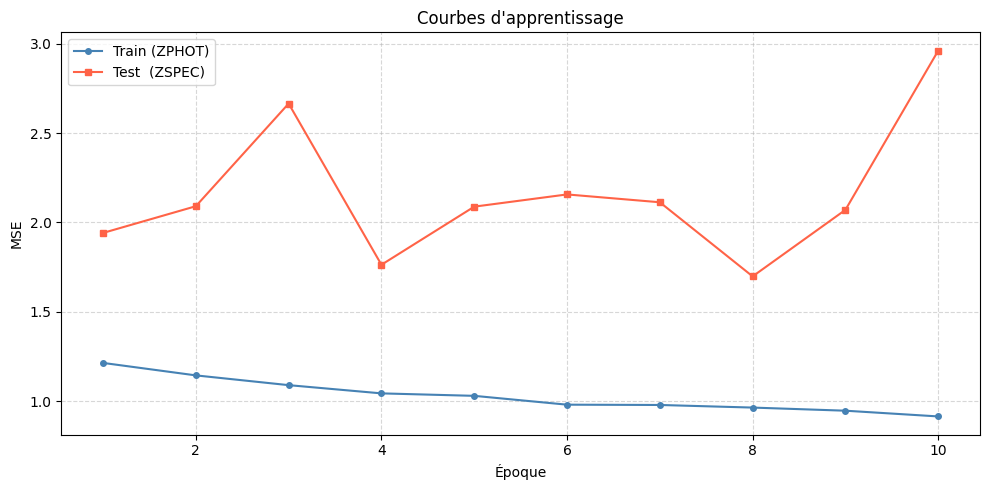

In [8]:
ep = range(1, EPOCHS + 1)
plt.figure(figsize=(10, 5))
plt.plot(ep, train_losses, label="Train (ZPHOT)",  color="steelblue",  marker="o", markersize=4)
plt.plot(ep, test_losses,  label="Test  (ZSPEC)",  color="tomato",     marker="s", markersize=4)
plt.xlabel("Époque")
plt.ylabel("MSE")
plt.title("Courbes d'apprentissage")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Évaluation

In [9]:
model.eval()
with torch.no_grad():
    dummy_ebv  = torch.zeros(X_test_t.size(0), device=device)
    _, out_reg = model(X_test_t.to(device), ebv=dummy_ebv)

z_phot = out_reg.cpu().numpy().flatten()
z_spec = y_test_t.numpy().flatten()

delta_z      = z_phot - z_spec
norm_abs     = np.abs(delta_z) / (1.0 + z_spec)

sigma_nmad   = 1.4826 * np.median(norm_abs)
biais        = np.median(delta_z / (1.0 + z_spec))
outliers_pct = np.mean(norm_abs > 0.15) * 100

print(f"Objets évalués        : {len(z_spec)}")
print(f"Sigma_NMAD            : {sigma_nmad:.4f}")
print(f"Biais médian          : {biais:.4f}")
print(f"Fraction d'outliers   : {outliers_pct:.2f}%  (|Δz|/(1+z) > 0.15)")

print("\nAperçu des 5 premières prédictions :")
print(f"{'Z_SPEC':>10}  {'Z_PHOT':>10}  {'|Δz|/(1+z)':>12}")
for i in range(min(5, len(z_spec))):
    print(f"{z_spec[i]:10.4f}  {z_phot[i]:10.4f}  {norm_abs[i]:12.4f}")

Objets évalués        : 48
Sigma_NMAD            : 1.0109
Biais médian          : 0.6818
Fraction d'outliers   : 100.00%  (|Δz|/(1+z) > 0.15)

Aperçu des 5 premières prédictions :
    Z_SPEC      Z_PHOT    |Δz|/(1+z)
    0.4949      1.3464        0.5696
    0.0331      1.4527        1.3742
    0.7186      3.8573        1.8264
    0.0522      3.2007        2.9923
    0.6187      1.4095        0.4885


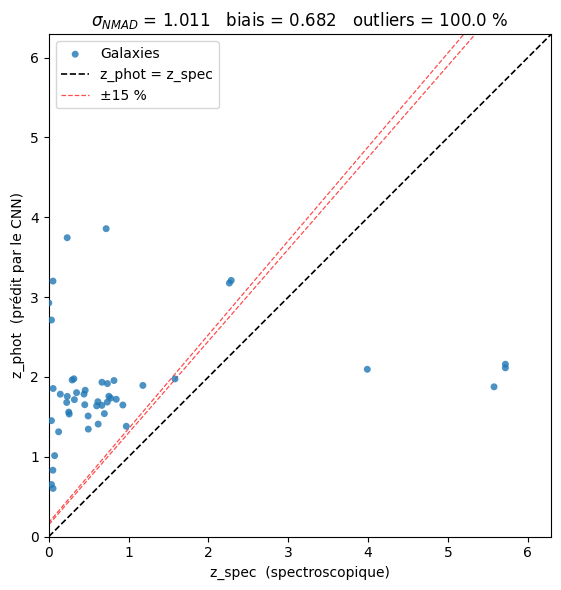

In [10]:
lim = max(z_spec.max(), z_phot.max()) * 1.1
z_range = np.linspace(0, lim, 200)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(z_spec, z_phot, s=25, alpha=0.8, edgecolors="none", zorder=3, label="Galaxies")
ax.plot(z_range, z_range,                       "k--",  lw=1.2, label="z_phot = z_spec")
ax.plot(z_range, 1.15 * z_range + 0.15,         "r--",  lw=0.9, alpha=0.7)
ax.plot(np.maximum(0, 0.85 * z_range - 0.15), z_range, "r--",  lw=0.9, alpha=0.7, label="±15 %")

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("z_spec  (spectroscopique)")
ax.set_ylabel("z_phot  (prédit par le CNN)")
ax.set_title(
    f"$\\sigma_{{NMAD}}$ = {sigma_nmad:.3f}   "
    f"biais = {biais:.3f}   "
    f"outliers = {outliers_pct:.1f} %"
)
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 7. Classification avec 200 bins

On discrétise le redshift en **200 bins** uniformes sur [0, 6]  
et on entraîne la tête de classification du modèle avec une `CrossEntropyLoss`.  
La prédiction finale est le **centre du bin** avec la probabilité maximale.

In [10]:
N_BINS      = 200
Z_MIN       = 0.0
Z_MAX       = 6.0

bin_edges   = np.linspace(Z_MIN, Z_MAX, N_BINS + 1)   # 201 bornes
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])  # 200 centres

def z_to_bin(z_arr):
    idx = np.digitize(z_arr, bin_edges) - 1
    return np.clip(idx, 0, N_BINS - 1)

y_train_cls = z_to_bin(y_train)
y_test_cls  = z_to_bin(y_test)

print(f'N_BINS           : {N_BINS}')
print(f'Largeur d un bin : {bin_edges[1]-bin_edges[0]:.4f}')
print(f'Labels train     : min={y_train_cls.min()}  max={y_train_cls.max()}')
print(f'Labels test      : min={y_test_cls.min()}   max={y_test_cls.max()}')


N_BINS           : 200
Largeur d un bin : 0.0300
Labels train     : min=0  max=198
Labels test      : min=0   max=190


In [11]:
y_train_cls_t = torch.tensor(y_train_cls, dtype=torch.long)
y_test_cls_t  = torch.tensor(y_test_cls,  dtype=torch.long)

train_ds_cls     = TensorDataset(X_train_t, y_train_cls_t)
train_loader_cls = DataLoader(
    train_ds_cls,
    batch_size=config.CONFIG['BATCH_SIZE'],
    shuffle=True,
    num_workers=config.CONFIG['NUM_WORKERS'],
    pin_memory=config.CONFIG['PIN_MEMORY'],
)

# Nouveau modèle avec n_outputs = N_BINS (tête classification)
model_cls = Model_multi_modal_simple(
    in_dim=[64, 64],
    n_outputs=N_BINS,
    modalities=config.CONFIG['MODALITIES'],
    mags_input_size=config.CONFIG['MAGS_INPUT_SIZE'],
    parallel_before_inception_archi=config.CONFIG['PARALLEL_BEFORE_INCEPTION_ARCHI'],
    parallel_inception_archi=config.CONFIG['PARALLEL_INCEPTION_ARCHI'],
    parallel_pooling_before_inceptions=config.CONFIG['PARALLEL_POOLING_BEFORE_INCEPTIONS'],
    inception_archi=config.CONFIG['INCEPTION_ARCHI'],
    pooling_before_inceptions=config.CONFIG['POOLING_BEFORE_INCEPTIONS'],
    first_FC_dim=config.CONFIG['FIRST_FC_DIM'],
    classification_FCs_archi_=config.CONFIG['CLASSIFICATION_FCS_ARCHI'],
    regression_FCs_archi_=config.CONFIG['REGRESSION_FCS_ARCHI'],
).to(device)

n_params_cls = sum(p.numel() for p in model_cls.parameters() if p.requires_grad)
print(f'Parametres entrainables (cls) : {n_params_cls:,}')


self.in_dim [64, 64]
self.modalities 1
Parametres entrainables (cls) : 10,782,619


In [12]:
criterion_cls = nn.CrossEntropyLoss()
optimizer_cls = optim.Adam(model_cls.parameters(), lr=config.CONFIG["LR"])
EPOCHS_CLS    = config.CONFIG["EPOCHS"]

train_losses_cls, test_accs_cls, test_sigma_cls = [], [], []

print(f"Entrainement classification sur {device} - {EPOCHS_CLS} epoques")
print("-" * 75)

for epoch in range(EPOCHS_CLS):
    model_cls.train()
    running_cls = 0.0
    for bX, by in train_loader_cls:
        bX, by    = bX.to(device), by.to(device)
        dummy_ebv = torch.zeros(bX.size(0), device=device)
        optimizer_cls.zero_grad()
        out_c, _ = model_cls(bX, ebv=dummy_ebv)
        loss      = criterion_cls(out_c, by)
        loss.backward()
        optimizer_cls.step()
        running_cls += loss.item() * bX.size(0)

    epoch_train_cls = running_cls / len(train_loader_cls.dataset)
    train_losses_cls.append(epoch_train_cls)

    model_cls.eval()
    with torch.no_grad():
        dummy_ebv_t   = torch.zeros(X_test_t.size(0), device=device)
        out_c_test, _ = model_cls(X_test_t.to(device), ebv=dummy_ebv_t)
        preds_cls     = out_c_test.argmax(dim=1).cpu().numpy()
        acc           = (torch.tensor(preds_cls) == y_test_cls_t).float().mean().item() * 100

    z_pred_ep   = bin_centers[preds_cls]
    norm_abs_ep = np.abs(z_pred_ep - y_test) / (1.0 + y_test)
    sigma_ep    = 1.4826 * np.median(norm_abs_ep)

    test_accs_cls.append(acc)
    test_sigma_cls.append(sigma_ep)

    print(f"Epoque [{epoch+1:3d}/{EPOCHS_CLS}]  CE : {epoch_train_cls:.4f}  |  Acc : {acc:.1f}%  |  Sigma_NMAD : {sigma_ep:.4f}")

print("-" * 75)
print("Entrainement classification termine.")


Entrainement classification sur cuda - 30 epoques
---------------------------------------------------------------------------
Epoque [  1/30]  CE : 4.6370  |  Acc : 3.7%  |  Sigma_NMAD : 0.6491
Epoque [  2/30]  CE : 4.4192  |  Acc : 0.0%  |  Sigma_NMAD : 0.5003
Epoque [  3/30]  CE : 4.3576  |  Acc : 11.1%  |  Sigma_NMAD : 0.5003
Epoque [  4/30]  CE : 4.3090  |  Acc : 3.7%  |  Sigma_NMAD : 0.8471
Epoque [  5/30]  CE : 4.2762  |  Acc : 0.0%  |  Sigma_NMAD : 0.5699
Epoque [  6/30]  CE : 4.2238  |  Acc : 0.0%  |  Sigma_NMAD : 0.4559
Epoque [  7/30]  CE : 4.1139  |  Acc : 7.4%  |  Sigma_NMAD : 0.4329
Epoque [  8/30]  CE : 3.9915  |  Acc : 7.4%  |  Sigma_NMAD : 0.3274
Epoque [  9/30]  CE : 3.9174  |  Acc : 3.7%  |  Sigma_NMAD : 0.2751
Epoque [ 10/30]  CE : 3.8501  |  Acc : 7.4%  |  Sigma_NMAD : 0.4106
Epoque [ 11/30]  CE : 3.7978  |  Acc : 7.4%  |  Sigma_NMAD : 0.1682
Epoque [ 12/30]  CE : 3.7352  |  Acc : 7.4%  |  Sigma_NMAD : 0.3618
Epoque [ 13/30]  CE : 3.6921  |  Acc : 0.0%  |  Sigma_NMA

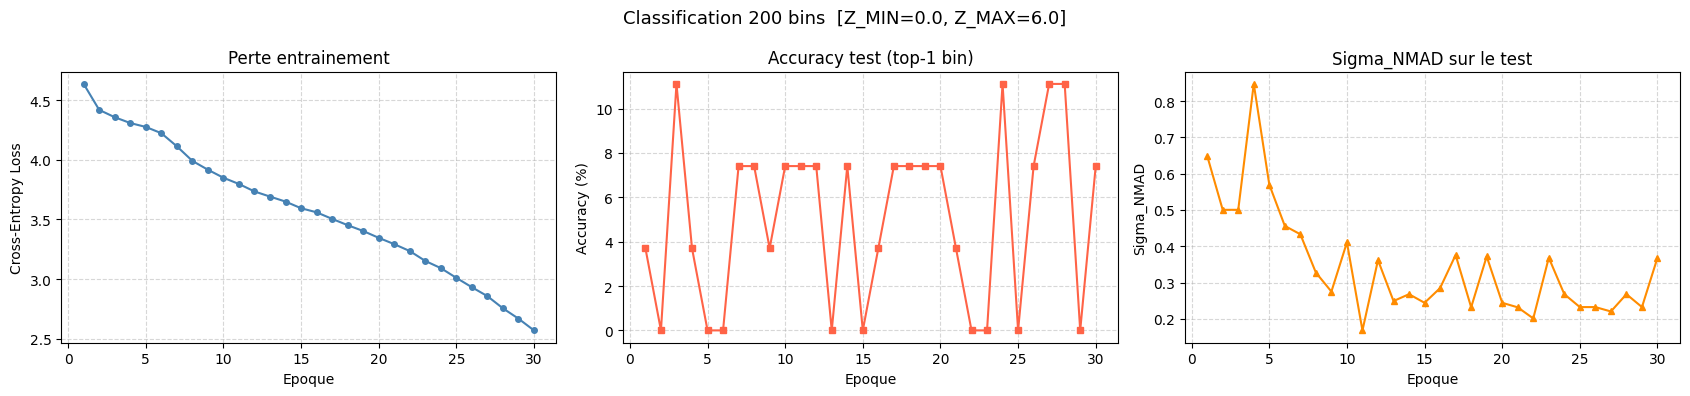

In [15]:
ep_cls = range(1, EPOCHS_CLS + 1)
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(ep_cls, train_losses_cls, color="steelblue", marker="o", markersize=4)
axes[0].set_xlabel("Epoque")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Perte entrainement")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(ep_cls, test_accs_cls, color="tomato", marker="s", markersize=4)
axes[1].set_xlabel("Epoque")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy test (top-1 bin)")
axes[1].grid(True, linestyle="--", alpha=0.5)

axes[2].plot(ep_cls, test_sigma_cls, color="darkorange", marker="^", markersize=4)
axes[2].set_xlabel("Epoque")
axes[2].set_ylabel("Sigma_NMAD")
axes[2].set_title("Sigma_NMAD sur le test")
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.suptitle(f"Classification {N_BINS} bins  [Z_MIN={Z_MIN}, Z_MAX={Z_MAX}]", fontsize=13)
plt.tight_layout()
plt.show()


Objets evalues           : 27
Sigma_NMAD  (cls)        : 0.3683
Biais median (cls)       : 0.1807
Fraction outliers (cls)  : 77.78%  (|dz|/(1+z) > 0.15)


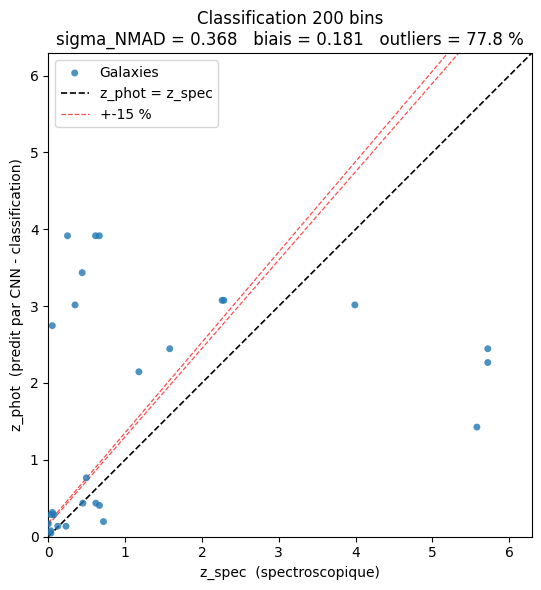

In [16]:
model_cls.eval()
with torch.no_grad():
    dummy_ebv     = torch.zeros(X_test_t.size(0), device=device)
    out_c_eval, _ = model_cls(X_test_t.to(device), ebv=dummy_ebv)
    pred_bins     = out_c_eval.argmax(dim=1).cpu().numpy()

z_phot_cls = bin_centers[pred_bins]  # valeurs continues reconstruites
z_spec_cls = y_test

delta_z_cls  = z_phot_cls - z_spec_cls
norm_abs_cls = np.abs(delta_z_cls) / (1.0 + z_spec_cls)

sigma_nmad_cls   = 1.4826 * np.median(norm_abs_cls)
biais_cls        = np.median(delta_z_cls / (1.0 + z_spec_cls))
outliers_pct_cls = np.mean(norm_abs_cls > 0.15) * 100

print(f'Objets evalues           : {len(z_spec_cls)}')
print(f'Sigma_NMAD  (cls)        : {sigma_nmad_cls:.4f}')
print(f'Biais median (cls)       : {biais_cls:.4f}')
print(f'Fraction outliers (cls)  : {outliers_pct_cls:.2f}%  (|dz|/(1+z) > 0.15)')

lim_cls     = max(z_spec_cls.max(), z_phot_cls.max()) * 1.1
z_range_cls = np.linspace(0, lim_cls, 200)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(z_spec_cls, z_phot_cls, s=25, alpha=0.8, edgecolors='none', zorder=3, label='Galaxies')
ax.plot(z_range_cls, z_range_cls, 'k--', lw=1.2, label='z_phot = z_spec')
ax.plot(z_range_cls, 1.15 * z_range_cls + 0.15, 'r--', lw=0.9, alpha=0.7)
ax.plot(np.maximum(0, 0.85 * z_range_cls - 0.15), z_range_cls, 'r--', lw=0.9, alpha=0.7, label='+-15 %')
ax.set_xlim(0, lim_cls)
ax.set_ylim(0, lim_cls)
ax.set_xlabel('z_spec  (spectroscopique)')
ax.set_ylabel('z_phot  (predit par CNN - classification)')
ax.set_title(
    f'Classification {N_BINS} bins\n'
    f'sigma_NMAD = {sigma_nmad_cls:.3f}   '
    f'biais = {biais_cls:.3f}   '
    f'outliers = {outliers_pct_cls:.1f} %'
)
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()
